# Ultrasonic Meter Wet Gas Over-Reading Correction (Van Putten)

An ultrasonic meter placed in wet gas reads too high, because the liquid occupies part of the pipe cross section. This example demonstrates the Van Putten over-reading correction, which converts the indicated gas volume flow into the actual gas volume flow.

The correction is available in two variants, which differ only in how the critical gas Froude number is obtained:

- from the water-liquid ratio, Equation (27)
- from the gas Ohnesorge number, Equations (25)-(26)

Reference: van Putten et al., *Ultrasonic Meters in Wet Gas Application*, North Sea Flow Measurement Workshop, 2015. [Paper](https://nfogm.no/wp-content/uploads/2019/02/2015-02-Ultrasonic-Meters-in-Wet-Gas-Application-van-Putten-DNV-GL.pdf)

## Equations

The gas void fraction determines the over-reading, Equations (29)-(30):

$$\chi(X)=\frac{1}{1+X}-X^{0.76}+1.44X$$

$$\alpha_g=\begin{cases}\chi, & Fr_g<Fr_g^*\\[4pt](\chi-GVF)\,e^{-0.4(Fr_g-Fr_g^*)}+GVF, & Fr_g\ge Fr_g^*\end{cases}$$

$$OR=\frac{Q_{g,indicated}}{Q_{g,actual}}=\frac{1}{\alpha_g}$$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pvtlib import fluid_mechanics
from pvtlib.metering import ultrasonic_flowmeters

## Over-reading surface

Over-reading as a function of gas Froude number and Lockhart-Martinelli parameter, for a hydrocarbon liquid at a density ratio of 0.02. The axis ranges follow Figure 5-5 of the paper and extend beyond the JIP test range.

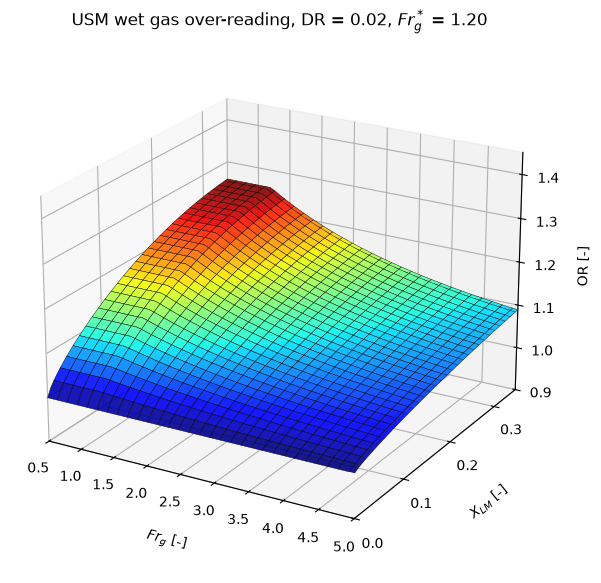

In [2]:
DR = 0.02  # Density ratio rho_gas/rho_liquid [-]
Fr_crit = ultrasonic_flowmeters.critical_froude_from_WLR_VanPutten(WLR=0.0)

Fr_grid, X_grid = np.meshgrid(np.linspace(0.5, 5.0, 60), np.linspace(0.0, 0.35, 60), indexing='ij')
OR_grid = np.zeros_like(Fr_grid)

for i, j in np.ndindex(Fr_grid.shape):
    # The gas volume fraction must be consistent with X at the chosen density ratio
    GVF_ij = fluid_mechanics.GVF_from_lockhart_martinelli(X_grid[i, j], density_liquid=1.0, density_gas=DR)
    OR_grid[i, j] = 1 / ultrasonic_flowmeters.gas_void_fraction_VanPutten(X_grid[i, j], Fr_grid[i, j], GVF_ij, Fr_crit)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Fr_grid, X_grid, OR_grid, cmap='jet', rstride=2, cstride=2, linewidth=0.3, edgecolors='k', alpha=0.9)
ax.set_xlabel('$Fr_g$ [-]', labelpad=12)
ax.set_ylabel('$X_{LM}$ [-]', labelpad=12)
ax.set_zlabel('OR [-]', labelpad=8)
ax.set_xlim(0.5, 5.0)
ax.set_ylim(0.0, 0.35)
ax.set_zlim(0.9, 1.45)
ax.set_yticks([0, 0.1, 0.2, 0.3])
ax.set_zticks([0.9, 1.0, 1.1, 1.2, 1.3, 1.4])
ax.view_init(elev=22, azim=-60)
ax.set_title(f'USM wet gas over-reading, DR = {DR}, $Fr_g^*$ = {Fr_crit:.2f}')
plt.show()

## Case

An ultrasonic meter reads 1000 m3/h of gas. The liquid loading is known from another source. The liquid is an oil-water mixture. Gas-liquid interfacial tension is estimated using a simplified linear rule, weighting the gas-oil and gas-water values by their liquid volume-flow fractions (1 - WLR and WLR). This is an approximation, not a general interfacial-property model.

In [3]:
D = 0.15  # Inner pipe diameter [m]
rho_g = 20.0  # Gas density at line conditions [kg/m3]
rho_oil = 800.0  # Oil density at line conditions [kg/m3]
rho_water = 1030.0  # Water density at line conditions [kg/m3]
WLR = 0.5  # Water volume flow / total liquid volume flow [-]
GVF = 0.99  # Gas volume flow / total volume flow [-]
VolFlow_gas_measured = 1000.0  # Indicated gas volume flow at line conditions [m3/h]
mu_g = 1.2e-5  # Gas viscosity at line conditions [Pa.s]
ST_oil = 0.025  # Gas-oil surface tension [N/m]
ST_water = 0.055  # Gas-water surface tension [N/m]

rho_l = fluid_mechanics.mixture_density_homogeneous([1 - WLR, WLR], [rho_oil, rho_water])
ST_liquid = fluid_mechanics.gas_liquid_interfacial_tension_linear_mixing(WLR, ST_oil, ST_water)

print(f'Liquid density: {rho_l:.1f} kg/m3')
print(f'Liquid surface tension: {ST_liquid:.3f} N/m')

Liquid density: 915.0 kg/m3
Liquid surface tension: 0.040 N/m


## Correction

The critical Froude number is calculated both ways. The WLR variant is the default, while the Ohnesorge variant is passed in explicitly.

In [4]:
Fr_crit_Ohnesorge = ultrasonic_flowmeters.critical_froude_from_Ohnesorge_VanPutten(rho_g, mu_g, ST_liquid, D)

results = {
    'Equation (27), WLR': ultrasonic_flowmeters.calculate_flow_wetgas_USM_VanPutten_2015(
        VolFlow_gas_measured=VolFlow_gas_measured, D=D, rho_g=rho_g, rho_l=rho_l,
        GVF=GVF, WLR=WLR, check_input=True),
    'Equation (26), Ohnesorge': ultrasonic_flowmeters.calculate_flow_wetgas_USM_VanPutten_2015(
        VolFlow_gas_measured=VolFlow_gas_measured, D=D, rho_g=rho_g, rho_l=rho_l,
        GVF=GVF, Fr_gas_crit=Fr_crit_Ohnesorge, check_input=True),
}

keys = ['LockhartMartinelli', 'DR', 'Fr_gas', 'Fr_gas_crit', 'alpha_gas', 'OverRead',
        'VolFlow_gas_corrected', 'within_JIP_envelope']
pd.DataFrame({name: {key: result[key] for key in keys} for name, result in results.items()})

,"Equation (27), WLR","Equation (26), Ohnesorge"
LockhartMartinelli,0.068322,0.068322
DR,0.021858,0.021858
Fr_gas,1.778197,1.752071
Fr_gas_crit,1.35,1.854292
alpha_gas,0.917819,0.904334
OverRead,1.089539,1.105786
VolFlow_gas_corrected,917.819352,904.334455
within_JIP_envelope,True,True


The gas Froude number falls between the two critical values, so the WLR variant uses the dispersed branch while the Ohnesorge variant uses the stratified branch. The two therefore give different corrected flow rates.

`within_JIP_envelope` only confirms that GVF, X, density ratio and gas Froude number are inside the ranges reported from the JIP tests. Meter type, pipe size, installation and fluids still require engineering assessment.